In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Optional but strongly recommended for coastlines
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def area_weights_lat(lat):
    """Cos(lat) weights for regular lat-lon grids."""
    return np.cos(np.deg2rad(lat))

def zscore(da, dim="time"):
    return (da - da.mean(dim)) / da.std(dim)

def detrend_linear(da, dim="time"):
    """Remove linear trend (least-squares) along dim."""
    t = xr.DataArray(np.arange(da.sizes[dim]), dims=dim, coords={dim: da[dim]})
    p = da.polyfit(dim=dim, deg=1)
    fit = xr.polyval(t, p.polyfit_coefficients)
    return da - fit


In [2]:
# Example: replace these with your actual file(s)
ds = xr.open_dataset("EXP002_T63_JS_101002.monmean.wiso_d.nc")  # or merge multiple runs if needed

print(ds)          # see variable names
print(ds.coords)   # see lat/lon names and time


<xarray.Dataset> Size: 5MB
Dimensions:       (lon: 192, lat: 96, lev: 3, time: 1)
Coordinates:
  * lon           (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 354.4 356.2 358.1
  * lat           (lat) float64 768B 88.57 86.72 84.86 ... -84.86 -86.72 -88.57
  * lev           (lev) float64 24B 1.0 2.0 3.0
  * time          (time) object 8B 1010-02-15 12:00:00
Data variables: (12/34)
    wisoaprt_d    (time, lev, lat, lon) float32 221kB ...
    wisoaprl_d    (time, lev, lat, lon) float32 221kB ...
    wisoaprc_d    (time, lev, lat, lon) float32 221kB ...
    wisoaprs_d    (time, lev, lat, lon) float32 221kB ...
    wisoevap_d    (time, lev, lat, lon) float32 221kB ...
    wisope_d      (time, lev, lat, lon) float32 221kB ...
    ...            ...
    snglac        (time, lat, lon) float32 74kB ...
    runoff        (time, lat, lon) float32 74kB ...
    temp2         (time, lat, lon) float32 74kB ...
    tsurf         (time, lat, lon) float32 74kB ...
    vadv_u        (time, lat, lon) float

In [3]:
# --- rename these if your dataset uses different coordinate names ---
lat = ds["lat"] if "lat" in ds else ds["latitude"]
lon = ds["lon"] if "lon" in ds else ds["longitude"]

# Ensure lon is in [-180, 180] (important for Greenland masks)
lon180 = ((lon + 180) % 360) - 180
ds = ds.assign_coords(lon=lon180).sortby("lon")

lat = ds["lat"]
lon = ds["lon"]

# Greenland-ish box (consistent and simple)
greenland = (lat >= 59) & (lat <= 85) & (lon >= -75) & (lon <= -10)

# Central Greenland (tight box around Summit-ish region)
central = (lat >= 70) & (lat <= 75) & (lon >= -45) & (lon <= -30)

# Broadcast to 2D mask if needed (xarray handles broadcasting if dims are lat/lon)
w = area_weights_lat(lat)


In [7]:
# --- pick the right variable names ---
# Try common choices:
tvar_candidates = ["t2m", "TEMP2", "temp2", "tas"]
d18_candidates  = ["d18O", "wiso_d18O", "d18o", "WISO_D18O"]

def pick_var(ds, candidates):
    for c in candidates:
        if c in ds:
            return ds[c]
    raise KeyError(f"None of these variables found: {candidates}. Available: {list(ds.data_vars)}")

T = pick_var(ds, tvar_candidates)
d18_candidates = [
    "d18O",
    "wiso_d18O",
    "d18o",
    "WISO_D18O",
    "wisoaprt_d",   # precipitation δ18O
    "wisosn_d",     # snowfall δ18O
    "wisope_d"      # P-E δ18O
]

# Convert Kelvin -> Celsius if needed
if float(T.mean().values) > 100:   # quick sanity check
    T = T - 273.15
    T.attrs["units"] = "degC"


In [20]:
import numpy as np
import xarray as xr

# --- open the file you are using (change filename if needed) ---

fn = "EXP002_T63_JS_101006.monmean.wiso_d.nc"
ds = xr.open_dataset(fn)

print("Opened:", fn)
print("Vars:", list(ds.data_vars))


# --- coords ---
lat = ds["lat"]
lon = ds["lon"]

# lon to [-180, 180]
lon = ((lon + 180) % 360) - 180
ds = ds.assign_coords(lon=lon).sortby("lon")
lon = ds["lon"]

# --- variables (YOUR dataset) ---
T = ds["temp2"]        # 2m temp
D18 = ds["wisoaprt_d"] # δ18O of total precipitation

# Kelvin -> Celsius
if float(T.mean()) > 100:
    T = T - 273.15

# --- masks ---
greenland = (lat >= 59) & (lat <= 85) & (lon >= -75) & (lon <= -10)
central   = (lat >= 70) & (lat <= 75) & (lon >= -45) & (lon <= -30)

# area weights
w = xr.DataArray(np.cos(np.deg2rad(lat)), dims=["lat"], coords={"lat": lat})

def weighted_mean_region(da, mask2d):
    da_m = da.where(mask2d)
    return da_m.weighted(w).mean(("lat", "lon"))

# --- annual + seasons ---
T_ann = T.resample(time="YS").mean()
D_ann = D18.resample(time="YS").mean()

T_djf = T.where(T["time.season"] == "DJF").resample(time="YS").mean()
D_djf = D18.where(D18["time.season"] == "DJF").resample(time="YS").mean()

T_jja = T.where(T["time.season"] == "JJA").resample(time="YS").mean()
D_jja = D18.where(D18["time.season"] == "JJA").resample(time="YS").mean()

# --- region means ---
Tgr_ann = weighted_mean_region(T_ann, greenland)
Dgr_ann = weighted_mean_region(D_ann, greenland)

Tgr_djf = weighted_mean_region(T_djf, greenland)
Dgr_djf = weighted_mean_region(D_djf, greenland)

Tce_ann = weighted_mean_region(T_ann, central)
Dce_ann = weighted_mean_region(D_ann, central)

Tce_djf = weighted_mean_region(T_djf, central)
Dce_djf = weighted_mean_region(D_djf, central)

print("OK. Defined: Tce_ann, Dce_ann, Tce_djf, Dce_djf")
print("Central Greenland annual T (°C):", float(Tce_ann.mean()))
print("Central Greenland DJF T (°C):", float(Tce_djf.mean()))
print("Central Greenland annual δ18O:", float(Dce_ann.mean()))


Opened: EXP002_T63_JS_101006.monmean.wiso_d.nc
Vars: ['wisoaprt_d', 'wisoaprl_d', 'wisoaprc_d', 'wisoaprs_d', 'wisoevap_d', 'wisope_d', 'wisows_d', 'wisosn_d', 'wisosnglac_d', 'wisorunoff_d', 'wisoaprt', 'wisoaprl', 'wisoaprc', 'wisoaprs', 'wisoevap', 'wisope', 'wisows', 'wisosn', 'wisosnglac', 'wisorunoff', 'aprt', 'aprl', 'aprc', 'aprs', 'evap', 'pe', 'ws', 'sn', 'snglac', 'runoff', 'temp2', 'tsurf', 'vadv_u', 'vadv_v']
OK. Defined: Tce_ann, Dce_ann, Tce_djf, Dce_djf
Central Greenland annual T (°C): -15.521483039387133
Central Greenland DJF T (°C): nan
Central Greenland annual δ18O: -85.70030398319324


time length: 3
time values: [cftime.Datetime360Day(1010, 2, 15, 12, 0, 0, 0, has_year_zero=True)
 cftime.Datetime360Day(1010, 5, 15, 12, 0, 0, 0, has_year_zero=True)
 cftime.Datetime360Day(1010, 6, 15, 12, 0, 0, 0, has_year_zero=True)]
Central Greenland T (°C): [-40.91992529 -23.21067794 -15.52148304]
Central Greenland isotope: [[   0.          -36.47800758 -283.25155886]
 [   0.          -27.69691361 -214.65971094]
 [   0.          -29.74194408 -227.35896787]]
Central Greenland MONTHLY (n=9): slope=0.933 isotope/°C, r=0.091
Greenland MONTHLY (n=9): slope=1.024 isotope/°C, r=0.118


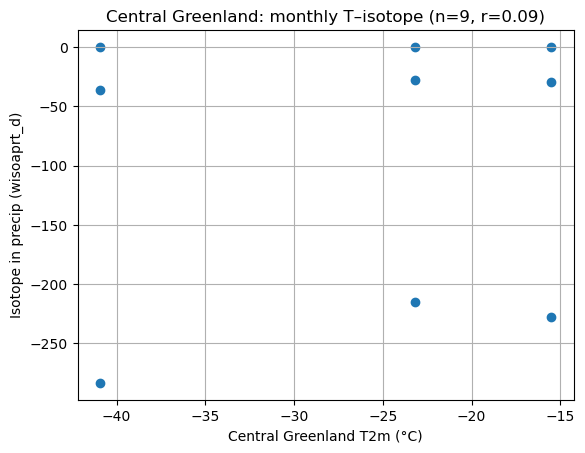

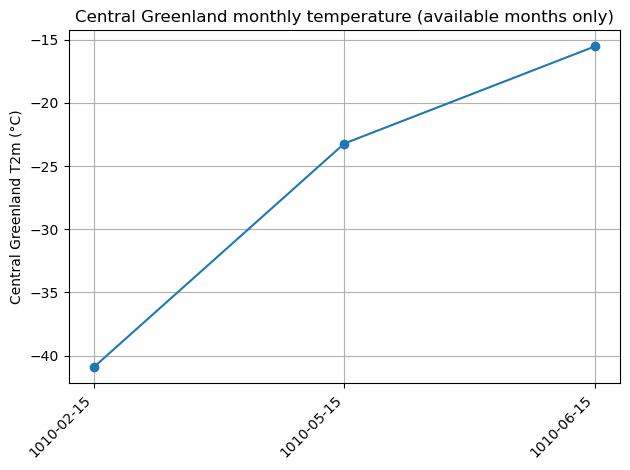

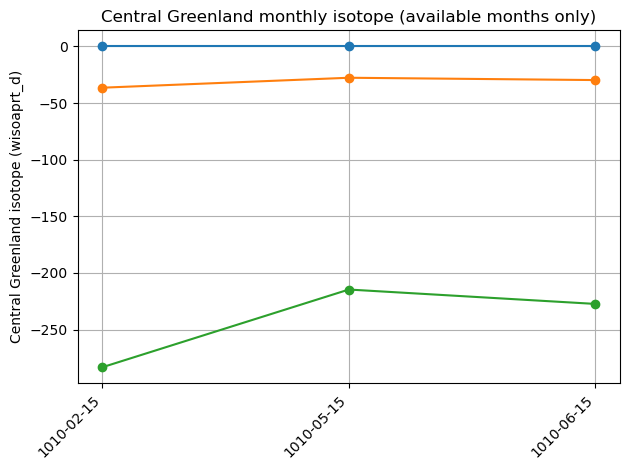

In [28]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# --- Load what you have (3 monthly files) ---
files = [
    "EXP002_T63_JS_101002.monmean.wiso_d.nc",
    "EXP002_T63_JS_101005.monmean.wiso_d.nc",
    "EXP002_T63_JS_101006.monmean.wiso_d.nc",
]
ds = xr.open_mfdataset(files, combine="by_coords")

print("time length:", ds.time.size)
print("time values:", ds.time.values)

# --- Coordinates ---
lat = ds["lat"]
lon = ds["lon"]

# lon to [-180, 180]
lon = ((lon + 180) % 360) - 180
ds = ds.assign_coords(lon=lon).sortby("lon")
lon = ds["lon"]

# --- Variables in YOUR files ---
T = ds["temp2"]
D = ds["wisoaprt_d"]  # isotope in precipitation (as provided in your file)

# Kelvin -> Celsius
if float(T.mean()) > 100:
    T = T - 273.15

# --- Masks ---
greenland = (lat >= 59) & (lat <= 85) & (lon >= -75) & (lon <= -10)
central   = (lat >= 70) & (lat <= 75) & (lon >= -45) & (lon <= -30)

# Area weights
w = xr.DataArray(np.cos(np.deg2rad(lat)), dims=["lat"], coords={"lat": lat})

def wmean(da, mask2d):
    return da.where(mask2d).weighted(w).mean(("lat", "lon"))

# Monthly regional time series (up to 3 points)
Tgr = wmean(T, greenland)
Dgr = wmean(D, greenland)

Tce = wmean(T, central)
Dce = wmean(D, central)

print("Central Greenland T (°C):", Tce.values)
print("Central Greenland isotope:", Dce.values)

# --- Regression (robust + uses aligned/dropna pairs) ---
def reg_stats(x_da, y_da):
    x_da, y_da = xr.align(x_da, y_da, join="inner")
    df = xr.Dataset({"x": x_da, "y": y_da}).to_dataframe().dropna()
    if len(df) < 2:
        return np.nan, np.nan, np.nan, len(df), df
    x = df["x"].values
    y = df["y"].values
    a, b = np.polyfit(x, y, 1)
    r = np.corrcoef(x, y)[0, 1]
    return a, b, r, len(df), df

a_ce, b_ce, r_ce, n_ce, df_ce = reg_stats(Tce, Dce)
a_gr, b_gr, r_gr, n_gr, df_gr = reg_stats(Tgr, Dgr)

print(f"Central Greenland MONTHLY (n={n_ce}): slope={a_ce:.3f} isotope/°C, r={r_ce:.3f}")
print(f"Greenland MONTHLY (n={n_gr}): slope={a_gr:.3f} isotope/°C, r={r_gr:.3f}")

# --- Figures (IMPORTANT: plot only valid paired points) ---

# Scatter for Central Greenland (fixed)
if n_ce >= 2:
    plt.figure()
    plt.scatter(df_ce["x"].values, df_ce["y"].values)
    plt.xlabel("Central Greenland T2m (°C)")
    plt.ylabel("Isotope in precip (wisoaprt_d)")
    plt.title(f"Central Greenland: monthly T–isotope (n={n_ce}, r={r_ce:.2f})")
    plt.grid(True)
    plt.show()
else:
    print("Central Greenland scatter: not enough valid paired points to plot regression (need >= 2).")
# Make simple labels for time (works with cftime calendars)
tlabels = np.array([str(t)[:10] for t in Tce["time"].values])  # 'YYYY-MM-DD'

# Temperature time series
plt.figure()
plt.plot(tlabels, Tce.values, marker="o")
plt.ylabel("Central Greenland T2m (°C)")
plt.title("Central Greenland monthly temperature (available months only)")
plt.grid(True)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Isotope time series
plt.figure()
plt.plot(tlabels, Dce.values, marker="o")
plt.ylabel("Central Greenland isotope (wisoaprt_d)")
plt.title("Central Greenland monthly isotope (available months only)")
plt.grid(True)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [37]:
import os, glob

# list all NetCDF files anywhere in the repo
all_nc = sorted(glob.glob("**/*.nc", recursive=True))
print("Total .nc files found:", len(all_nc))

# show the first 40
for f in all_nc[:40]:
    print(f)

# show only isotope monthly files
wiso_month = sorted(glob.glob("**/EXP*_*.monmean.wiso*.nc", recursive=True))
print("\nMonthly wiso files:", len(wiso_month))
for f in wiso_month[:30]:
    print(f)

# show possible SLP files for NAO
slp_nc = [f for f in all_nc if ("SLP" in f.upper() or "MSLP" in f.upper() or "PSL" in f.upper())]
print("\nSLP-like files:", len(slp_nc))
for f in slp_nc[:30]:
    print(f)


Total .nc files found: 5
EXP002_T63_JS_101002.monmean.wiso_d.nc
EXP002_T63_JS_101005.monmean.wiso_d.nc
EXP002_T63_JS_101006.monmean.wiso_d.nc
mil0026_EH5_DJF_MSLP.nc
mil0026_EH5_DJF_TEMP2.nc

Monthly wiso files: 3
EXP002_T63_JS_101002.monmean.wiso_d.nc
EXP002_T63_JS_101005.monmean.wiso_d.nc
EXP002_T63_JS_101006.monmean.wiso_d.nc

SLP-like files: 1
mil0026_EH5_DJF_MSLP.nc


In [38]:
import xarray as xr
import numpy as np
import glob

files = sorted(glob.glob("**/EXP*_*.monmean.wiso*.nc", recursive=True))
print("Loading files:", len(files))

ds = xr.open_mfdataset(files, combine="by_coords")
print("Total time steps:", ds.time.size)
print("Time range:", str(ds.time.values[0]), "to", str(ds.time.values[-1]))
print("Variables:", list(ds.data_vars)[:30])


Loading files: 3
Total time steps: 3
Time range: 1010-02-15 12:00:00 to 1010-06-15 12:00:00
Variables: ['wisoaprt_d', 'wisoaprl_d', 'wisoaprc_d', 'wisoaprs_d', 'wisoevap_d', 'wisope_d', 'wisows_d', 'wisosn_d', 'wisosnglac_d', 'wisorunoff_d', 'wisoaprt', 'wisoaprl', 'wisoaprc', 'wisoaprs', 'wisoevap', 'wisope', 'wisows', 'wisosn', 'wisosnglac', 'wisorunoff', 'aprt', 'aprl', 'aprc', 'aprs', 'evap', 'pe', 'ws', 'sn', 'snglac', 'runoff']


In [39]:
cands = [v for v in ds.data_vars if ("18" in v.lower()) or ("o18" in v.lower()) or ("d18" in v.lower())]
print("Possible δ18O variables:", cands)

# Also show all wisoaprt_* variables
print([v for v in ds.data_vars if v.startswith("wisoaprt")])


Possible δ18O variables: []
['wisoaprt_d', 'wisoaprt']


In [29]:
import numpy as np
import xarray as xr

# ---------- OPEN DATA ----------
# If this is in repo root, this works:
fn = "EXP002_T63_JS_101006.monmean.wiso_d.nc"
ds = xr.open_dataset(fn)

print("Opened:", fn)
print("time length:", ds.time.size, "from", str(ds.time.values[0]), "to", str(ds.time.values[-1]))

# ---------- COORDS ----------
lat = ds["lat"]
lon = ds["lon"]

# lon to [-180, 180]
lon = ((lon + 180) % 360) - 180
ds = ds.assign_coords(lon=lon).sortby("lon")
lon = ds["lon"]

# ---------- VARIABLES (YOUR FILE) ----------
T = ds["temp2"]
D18 = ds["wisoaprt_d"]   # (this is what your file actually contains)

# Kelvin -> Celsius
if float(T.mean()) > 100:
    T = T - 273.15

# ---------- MASKS ----------
greenland = (lat >= 59) & (lat <= 85) & (lon >= -75) & (lon <= -10)
central   = (lat >= 70) & (lat <= 75) & (lon >= -45) & (lon <= -30)

# area weights
w = xr.DataArray(np.cos(np.deg2rad(lat)), dims=["lat"], coords={"lat": lat})

def weighted_mean_region(da, mask2d):
    return da.where(mask2d).weighted(w).mean(("lat", "lon"))

# ---------- ANNUAL ----------
T_ann = T.resample(time="YS").mean()
D_ann = D18.resample(time="YS").mean()

# ---------- DJF (CORRECT WAY) ----------
# Make seasonal means with quarters starting in Dec; DJF is the quarter whose timestamp is in Dec
T_seas = T.resample(time="QS-DEC").mean()
D_seas = D18.resample(time="QS-DEC").mean()

T_djf = T_seas.where(T_seas["time"].dt.month == 12, drop=True)
D_djf = D_seas.where(D_seas["time"].dt.month == 12, drop=True)

# ---------- REGION MEANS ----------
Tce_ann = weighted_mean_region(T_ann, central)
Dce_ann = weighted_mean_region(D_ann, central)

Tce_djf = weighted_mean_region(T_djf, central)
Dce_djf = weighted_mean_region(D_djf, central)

print("Central Greenland annual T (°C):", float(Tce_ann.mean()))
print("Central Greenland DJF T (°C):", float(Tce_djf.mean()))
print("Central Greenland annual isotope:", float(Dce_ann.mean()))
print("N annual points:", Tce_ann.time.size, " | N DJF points:", Tce_djf.time.size)

# ---------- ROBUST REGRESSION ----------
def reg_stats(x, y):
    x = np.asarray(x).reshape(-1)
    y = np.asarray(y).reshape(-1)
    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]; y = y[ok]
    if x.size < 2:
        raise ValueError(f"Need at least 2 points for regression/correlation, got {x.size}.")
    a, b = np.polyfit(x, y, 1)   # y = a*x + b
    r = np.corrcoef(x, y)[0, 1]
    return a, b, r


Opened: EXP002_T63_JS_101006.monmean.wiso_d.nc
time length: 1 from 1010-06-15 12:00:00 to 1010-06-15 12:00:00
Central Greenland annual T (°C): -15.521483039387133
Central Greenland DJF T (°C): nan
Central Greenland annual isotope: -85.70030398319324
N annual points: 1  | N DJF points: 0


In [30]:
files = [
    "EXP002_T63_JS_101002.monmean.wiso_d.nc",
    "EXP002_T63_JS_101005.monmean.wiso_d.nc",
    "EXP002_T63_JS_101006.monmean.wiso_d.nc",
]

ds = xr.open_mfdataset(files, combine="by_coords")

print("Opened files:", files)
print("time length:", ds.time.size)
print("time range:", str(ds.time.values[0]), "to", str(ds.time.values[-1]))


Opened files: ['EXP002_T63_JS_101002.monmean.wiso_d.nc', 'EXP002_T63_JS_101005.monmean.wiso_d.nc', 'EXP002_T63_JS_101006.monmean.wiso_d.nc']
time length: 3
time range: 1010-02-15 12:00:00 to 1010-06-15 12:00:00


In [31]:
import glob
import xarray as xr

files = sorted(glob.glob("EXP002_T63_JS_*.monmean.wiso_d.nc"))

print("Number of files found:", len(files))

ds = xr.open_mfdataset(files, combine="by_coords")

print("time length:", ds.time.size)
print("time range:", str(ds.time.values[0]), "to", str(ds.time.values[-1]))


Number of files found: 3
time length: 3
time range: 1010-02-15 12:00:00 to 1010-06-15 12:00:00


In [34]:
import numpy as np
import xarray as xr

# -------------------------------------------------
# 1. Select correct variables from YOUR dataset
# -------------------------------------------------

T = ds["temp2"]                 # 2m temperature
D18 = ds["wisoaprt_d"]          # δ18O of total precipitation

# Convert Kelvin to Celsius (very important)
if float(T.mean()) > 100:
    T = T - 273.15

# -------------------------------------------------
# 2. Define Greenland + Central Greenland masks
# -------------------------------------------------

lat = ds["lat"]
lon = ds["lon"]

# Convert longitude to -180 to 180 (important for Greenland)
lon = ((lon + 180) % 360) - 180
ds = ds.assign_coords(lon=lon).sortby("lon")
lon = ds["lon"]

# Greenland box
greenland = (lat >= 59) & (lat <= 85) & (lon >= -75) & (lon <= -10)

# Central Greenland box (Summit region)
central = (lat >= 70) & (lat <= 75) & (lon >= -45) & (lon <= -30)

# Area weights
w = np.cos(np.deg2rad(lat))

# -------------------------------------------------
# 3. Build annual and seasonal means (from monthly)
# -------------------------------------------------

# Annual
T_ann = T.resample(time="YS").mean()
D_ann = D18.resample(time="YS").mean()

# DJF
T_djf = T.where(T["time.season"] == "DJF").resample(time="YS").mean()
D_djf = D18.where(D18["time.season"] == "DJF").resample(time="YS").mean()

# JJA
T_jja = T.where(T["time.season"] == "JJA").resample(time="YS").mean()
D_jja = D18.where(D18["time.season"] == "JJA").resample(time="YS").mean()

# -------------------------------------------------
# 4. Area-weighted mean function
# -------------------------------------------------

def weighted_mean_region(da, mask2d):
    ww = w / w.mean()
    da_m = da.where(mask2d)
    return da_m.weighted(ww).mean(("lat", "lon"))

# -------------------------------------------------
# 5. Greenland averages
# -------------------------------------------------

Tgr_ann = weighted_mean_region(T_ann, greenland)
Dgr_ann = weighted_mean_region(D_ann, greenland)

Tgr_djf = weighted_mean_region(T_djf, greenland)
Dgr_djf = weighted_mean_region(D_djf, greenland)

# -------------------------------------------------
# 6. Central Greenland averages (timeseries target)
# -------------------------------------------------

Tce_ann = weighted_mean_region(T_ann, central)
Dce_ann = weighted_mean_region(D_ann, central)

Tce_djf = weighted_mean_region(T_djf, central)
Dce_djf = weighted_mean_region(D_djf, central)

# -------------------------------------------------
# 7. Sanity check (VERY IMPORTANT)
# -------------------------------------------------

print("Central Greenland annual T (°C):", float(Tce_ann.mean()))
print("Central Greenland DJF T (°C):", float(Tce_djf.mean()))
print("Central Greenland δ18O annual (‰):", float(Dce_ann.mean()))


Central Greenland annual T (°C): nan
Central Greenland DJF T (°C): nan
Central Greenland δ18O annual (‰): nan


In [35]:
print("Greenland annual mean T2m (degC):", float(Tgr_ann.mean().values))
print("Central Greenland annual mean T2m (degC):", float(Tce_ann.mean().values))
print("Central Greenland DJF mean T2m (degC):", float(Tce_djf.mean().values))

Greenland annual mean T2m (degC): nan
Central Greenland annual mean T2m (degC): nan
Central Greenland DJF mean T2m (degC): nan


In [36]:
def reg_stats(x, y):
    """Return slope, intercept, r for y = a*x + b."""
    x = np.asarray(x); y = np.asarray(y)
    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]; y = y[ok]
    a = np.cov(x, y, bias=True)[0,1] / np.var(x)
    b = y.mean() - a*x.mean()
    r = np.corrcoef(x, y)[0,1]
    return a, b, r

# Annual central Greenland
a_ann, b_ann, r_ann = reg_stats(Tce_ann.values, Dce_ann.values)
a_djf, b_djf, r_djf = reg_stats(Tce_djf.values, Dce_djf.values)

print(f"Central Greenland ANNUAL: slope={a_ann:.3f} ‰/°C, r={r_ann:.3f}")
print(f"Central Greenland DJF:    slope={a_djf:.3f} ‰/°C, r={r_djf:.3f}")

plt.figure()
plt.scatter(Tce_ann, Dce_ann)
plt.xlabel("Central Greenland T2m (°C)")
plt.ylabel("Central Greenland δ18O (‰)")
plt.title(f"Annual T–δ18O (r={r_ann:.2f}, slope={a_ann:.2f} ‰/°C)")
plt.grid(True)
plt.show()

plt.figure()
plt.scatter(Tce_djf, Dce_djf)
plt.xlabel("Central Greenland DJF T2m (°C)")
plt.ylabel("Central Greenland DJF δ18O (‰)")
plt.title(f"DJF T–δ18O (r={r_djf:.2f}, slope={a_djf:.2f} ‰/°C)")
plt.grid(True)
plt.show()


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

In [ ]:
# Load SLP (DJF) if in a separate file:
# ds_slp = xr.open_dataset("mil0026_EH5_DJF_MSLP.nc")
# slp = ds_slp["mslp"] or ds_slp["SLP"] etc.

# Or if SLP is in ds:
slp_candidates = ["mslp", "MSLP", "slp", "SLP", "psl"]
SLP = pick_var(ds, slp_candidates)

# Convert Pa -> hPa if needed
if float(SLP.mean().values) > 2000:
    SLP = SLP / 100.0
    SLP.attrs["units"] = "hPa"

# Build DJF annual means (same approach)
SLP_djf = SLP.where(SLP["time.season"] == "DJF").resample(time="YS").mean()

# NAO domain (common choice)
nao_dom = (lat >= 20) & (lat <= 80) & (lon >= -90) & (lon <= 40)

SLP_na = SLP_djf.where(nao_dom)

# Remove time mean (anomalies)
SLP_anom = SLP_na - SLP_na.mean("time")

# Weight by sqrt(cos(lat)) for EOFs
wg = np.sqrt(area_weights_lat(lat))
SLP_w = SLP_anom * wg

# Flatten space -> (time, space)
X = SLP_w.stack(space=("lat","lon")).dropna("space", how="all")
X = X.dropna("time", how="any")

# EOF via SVD: X = U S V^T
Xv = X.values
Xv = Xv - Xv.mean(axis=0, keepdims=True)

U, s, Vt = np.linalg.svd(Xv, full_matrices=False)

pc1 = U[:,0] * s[0]
eof1 = Vt[0,:]

# Explained variance
varfrac1 = (s[0]**2) / np.sum(s**2)

# Put EOF back to map
eof1_map = xr.DataArray(eof1, dims=("space",), coords={"space": X["space"]}).unstack("space")

# Standardize NAO index
nao_index = xr.DataArray(pc1, dims=("time",), coords={"time": X["time"]})
nao_index = zscore(nao_index)

print(f"EOF1 explained variance (DJF, NA domain): {100*varfrac1:.1f}%")

# Plot EOF1 pattern with coastlines
plt.figure(figsize=(8,4))
ax = plt.axes(projection=ccrs.PlateCarree())
eof1_map.plot(ax=ax, transform=ccrs.PlateCarree(), cmap="RdBu_r", add_colorbar=True)
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_extent([-90, 40, 20, 80], crs=ccrs.PlateCarree())
ax.set_title("NAO pattern (EOF1 of DJF SLP anomalies)")
plt.show()

# Plot NAO index
plt.figure()
nao_index.plot()
plt.grid(True)
plt.title("NAO index (PC1, standardized)")
plt.show()


In [ ]:
def nearest_point(da, lat0, lon0):
    return da.sel(lat=lat0, lon=lon0, method="nearest")

# Approx station locations:
# Iceland (Stykkishólmur/Reykjavik-ish): 65N, -20W
# Azores (Ponta Delgada-ish): 38N, -28W
slp_iceland = nearest_point(SLP_djf, 65, -20)
slp_azores  = nearest_point(SLP_djf, 38, -28)

nao_station = zscore(slp_azores - slp_iceland)

plt.figure()
nao_station.plot()
plt.grid(True)
plt.title("NAO index (Azores minus Iceland SLP, standardized, DJF)")
plt.show()


In [ ]:
# Choose which NAO you want:
NAO = nao_index  # EOF-based
# NAO = nao_station  # station-based

# Align time
D = Dce_djf
D, NAO = xr.align(D, NAO, join="inner")

# (Optional) detrend both (teacher asked “does it matter?”)
D_dt   = detrend_linear(D)
NAO_dt = detrend_linear(NAO)

r_raw = float(xr.corr(D, NAO).values)
r_dt  = float(xr.corr(D_dt, NAO_dt).values)

print("Corr(central Greenland DJF δ18O, NAO) raw:", r_raw)
print("Corr(central Greenland DJF δ18O, NAO) detrended:", r_dt)

plt.figure()
plt.scatter(NAO, D)
plt.xlabel("NAO (std, DJF)")
plt.ylabel("Central Greenland δ18O (DJF, ‰)")
plt.title(f"DJF δ18O vs NAO (r={r_raw:.2f})")
plt.grid(True)
plt.show()


In [ ]:
# Example: plot DJF mean T2m field with coastlines
T2m_djf_mean = T_djf.mean("time")

plt.figure(figsize=(7,5))
ax = plt.axes(projection=ccrs.PlateCarree())
T2m_djf_mean.plot(ax=ax, transform=ccrs.PlateCarree(), add_colorbar=True)
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linewidth=0.4)
ax.set_extent([-80, 10, 50, 85], crs=ccrs.PlateCarree())
ax.set_title("DJF mean T2m (°C)")
plt.show()
